# EN3160 Assignment 01: Intensity Transformations and Neighborhood Filtering

GUNATHUNGA U.A. - 230218G

GitHub Link: https://github.com/Upani-Gunathunga/EN3160-Assignment-01.git


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Question 1 

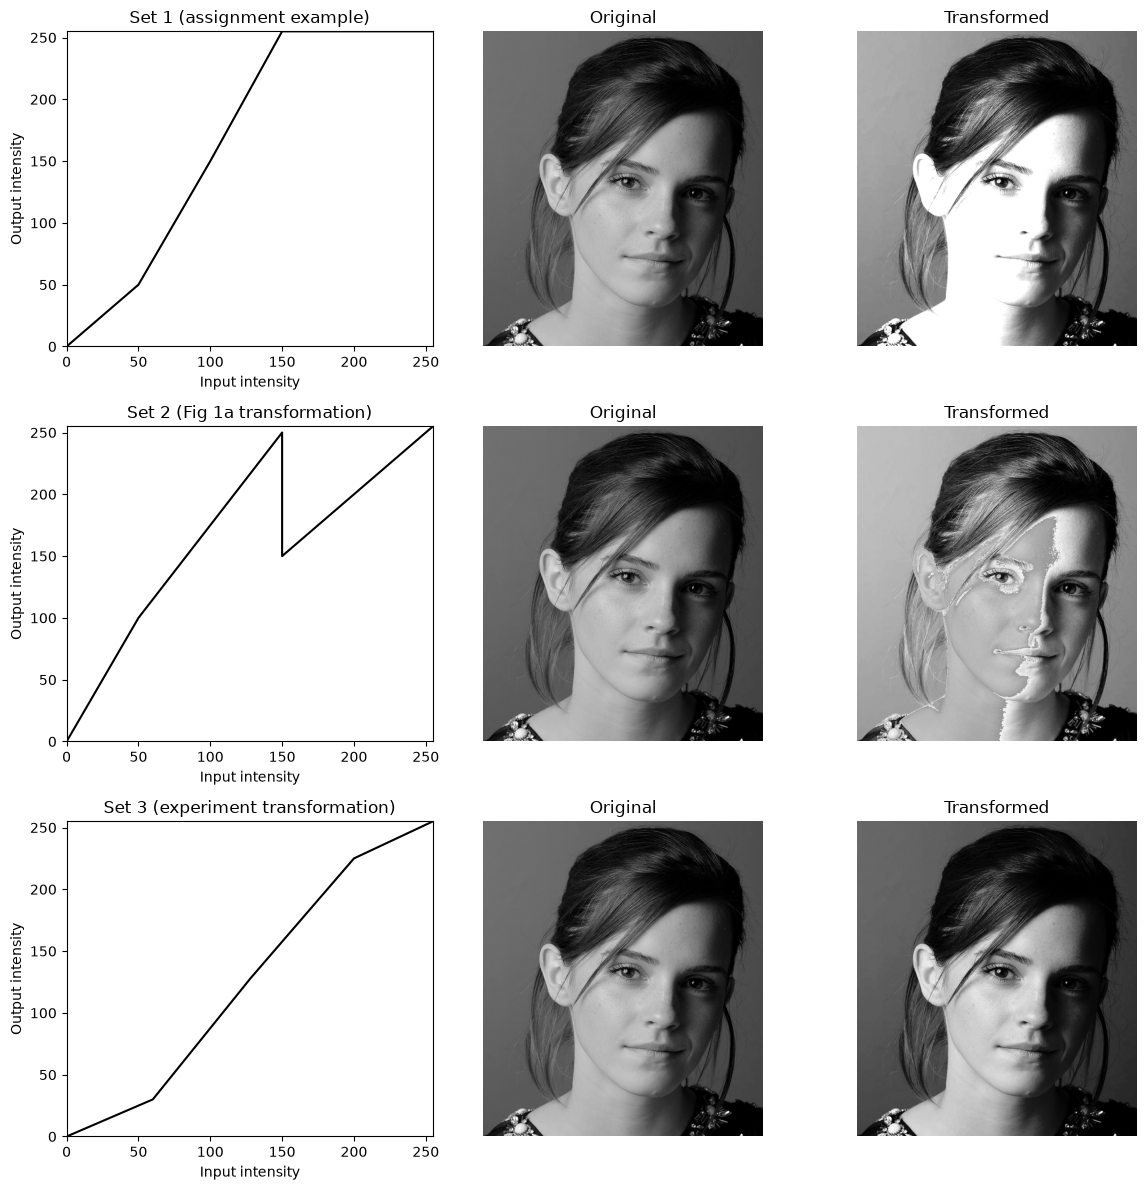

In [32]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
#experimenting with different breakpoints for intensity transformation

def intensity_transform(im, breakpoints):
    lut = np.zeros(256) # initialize a lookup table for all possible pixel values (0-255)
    for (x0, y0), (x1, y1) in zip(breakpoints, breakpoints[1:]):
        if x1 == x0:
            continue  # vertical line segments so skip drawing line
        idx = np.arange(x0, x1)
        lut[idx] = np.linspace(y0, y1, x1 - x0, endpoint=False)
        #construct straight line segments between breakpoints 
        # calculate values along it to complete lut
    lut[255] = breakpoints[-1][1]
    lut = np.clip(lut, 0, 255).astype(np.uint8)
    return cv2.LUT(im, lut)

face_input = cv2.imread("images/q1.jpeg", cv2.IMREAD_GRAYSCALE)

breakpoint_sets = {
    "Set 1 (assignment example)": [(0, 0), (50, 50), (100, 150), (150, 255), (255, 255)],
    "Set 2 (Fig 1a transformation)":    [(0, 0), (50, 100), (150, 250), (150, 150), (255, 255)],
    "Set 3 (experiment transformation)": [(0, 0), (60, 30), (128, 128), (200, 225), (255, 255)],
}

results = {}
for name, bp in breakpoint_sets.items():
    out = intensity_transform(face_input, bp)
    results[name] = (bp, out)

fig, axes = plt.subplots(len(results), 3, figsize=(12, 4 * len(results)))
for row, (name, (bp, out)) in enumerate(results.items()):
    x_plot, y_plot = zip(*bp)
    axes[row, 0].plot(x_plot, y_plot, color="black")
    axes[row, 0].set_xlim(0, 255)
    axes[row, 0].set_ylim(0, 255)
    axes[row, 0].set_title(name)
    axes[row, 0].set_xlabel("Input intensity")
    axes[row, 0].set_ylabel("Output intensity")

    axes[row, 1].imshow(face_input, cmap="gray")
    axes[row, 1].set_title("Original")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(out, cmap="gray")
    axes[row, 2].set_title("Transformed")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

Question 1

1. Key points in code: breakpoint sets tested for  Set 1 (assignment example), Set 2 (Fig 1a sawtooth), Set 3 (S-curve experiment). 

2. Comparison and interpretation: Set 3 gives balanced midtone contrast, shadows/highlights preserved. Set 1 clips highlights above input 150. Set 2's discontinuity at input 150 split face into two different.

3. Discussion: A pixel with a brightness of 149 gets boosted up to a very bright 249, but a pixel right next to it with a brightness of 150 instantly drops down to 150 hence, sawtooth  produces artificial seam. 
S-curve compresses extremes, expands midtones.

Question 02


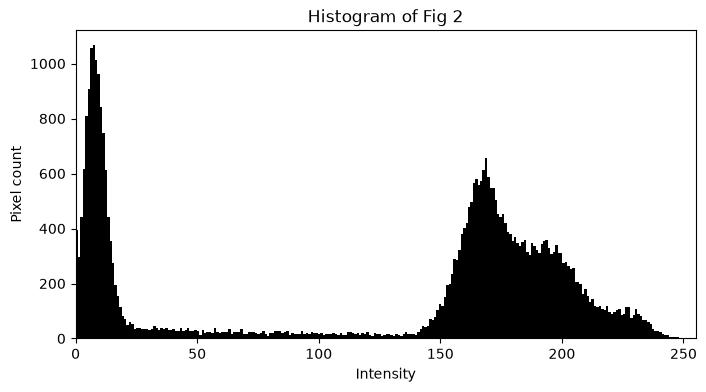

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

mri_input = cv2.imread("images/q2.jpeg", cv2.IMREAD_GRAYSCALE)

# plot histogram to know actual pixel intensity distribution of where white and gray matter is present
plt.figure(figsize=(8, 4))
plt.hist(mri_input.ravel(), bins=256, range=(0, 255), color="black")
plt.xlabel("Intensity")
plt.ylabel("Pixel count")
plt.title("Histogram of Fig 2")
plt.xlim(0, 255)
plt.show()

The plot shows that 150 - 250 region roughly represents both gray and white matter in which pixel intensities need to be more spreaded.

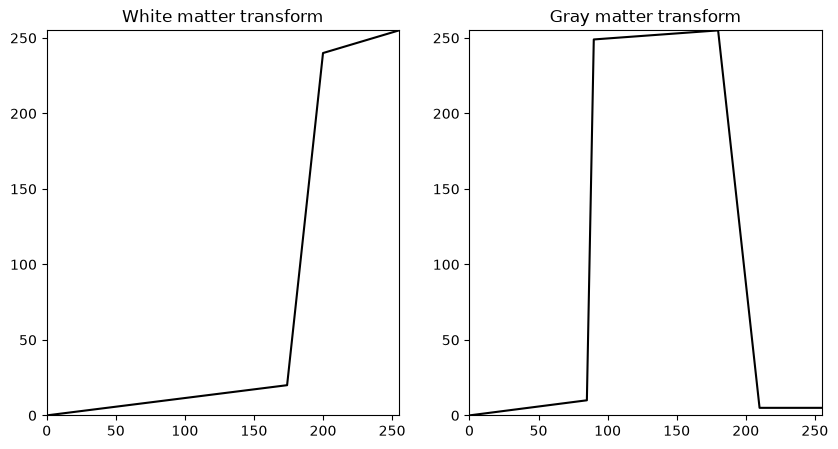

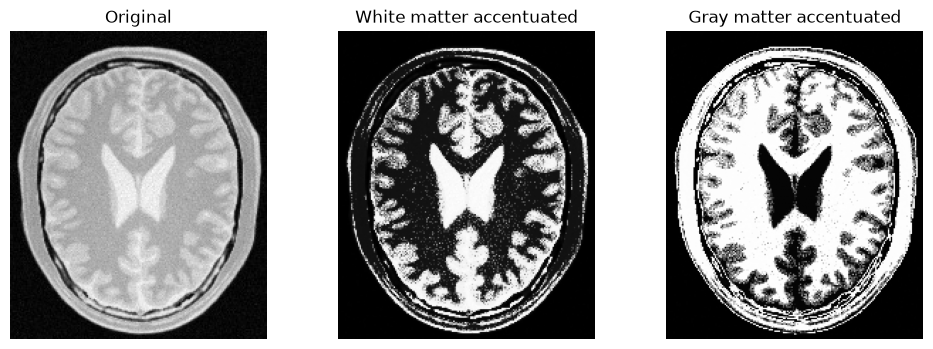

In [ ]:
mri_input = cv2.imread("images/q2.jpeg", cv2.IMREAD_GRAYSCALE)

# white_breaks = [(0, 0), (150, 60), (190, 230), (255, 255)]
# gray_breaks = [(0, 0), (90, 40), (130, 220), (170, 255), (255, 255)]
white_breaks = [(0, 0), (174, 20), (200, 240), (255, 255)]
# gray_breaks = [(0, 0), (180, 30), (250, 230), (255, 255)]  
gray_breaks = [(0, 0),(85, 10), (90, 249), (180, 255), (210, 5),(250, 5),(255, 0)]  
white_result = intensity_transform(mri_input, white_breaks)
gray_result = intensity_transform(mri_input, gray_breaks)

x_white, y_white = zip(*white_breaks)
x_gray, y_gray = zip(*gray_breaks)

fig_curves, axis_curves = plt.subplots(1, 2, figsize=(10, 5))
axis_curves[0].plot(x_white, y_white, color="black")
axis_curves[0].set_title("White matter transform")
axis_curves[0].set_xlim(0, 255)
axis_curves[0].set_ylim(0, 255)
axis_curves[1].plot(x_gray, y_gray, color="black")
axis_curves[1].set_title("Gray matter transform")
axis_curves[1].set_xlim(0, 255)
axis_curves[1].set_ylim(0, 255)
plt.show()

fig_tissue, axis_tissue = plt.subplots(1, 3, figsize=(12, 4))
axis_tissue[0].imshow(mri_input, cmap="gray")
axis_tissue[0].set_title("Original")
axis_tissue[0].axis("off")
axis_tissue[1].imshow(white_result, cmap="gray")
axis_tissue[1].set_title("White matter accentuated")
axis_tissue[1].axis("off")
axis_tissue[2].imshow(gray_result, cmap="gray")
axis_tissue[2].set_title("Gray matter accentuated")
axis_tissue[2].axis("off")
plt.show()

Question 2

1. Key points in code: breakpoints picked directly from histogram peaks 

2. Comparison and interpretation: white matter transform stretches 174-200 band, gray matter transform stretches lower band where each accentuates its target tissue .

3. Discussion: step function avoided due to partial volume effect at tissue boundaries, MRI intensities transition gradually. A hard step would amplify noise at edges. 

Question 03 - Transform the image into the CIELAB (L*a*b*)  color space and selectively apply transformation


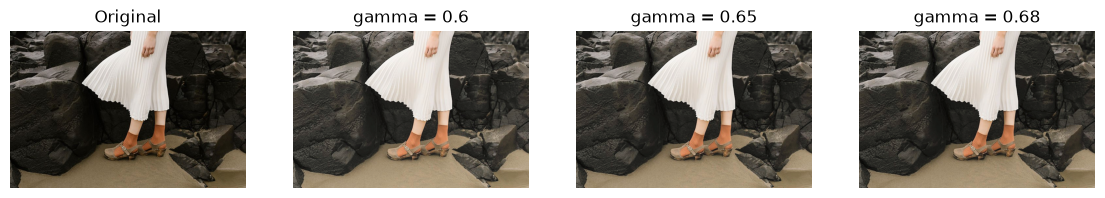

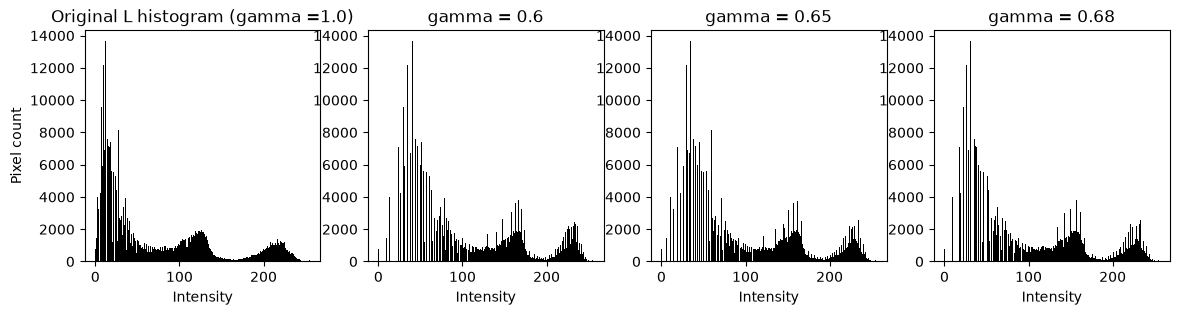

In [59]:
color_photo = cv2.imread("images/q3.jpeg")
lab_planes = cv2.cvtColor(color_photo, cv2.COLOR_BGR2LAB)
light_plane, a_plane, b_plane = cv2.split(lab_planes)

#Apply gamma correction to the L plane = light plane
#light_plane- Holds Lightness/Brightness values
#a_plane- Holds Green-to-Red color information
#b_plane- Holds Blue-to-Yellow color information

gamma_trials = [0.6, 0.65, 0.68]
corrected_lights = []
corrected_photos = []
for gamma_pick in gamma_trials:
    normalized_light = light_plane.astype(np.float32) / 255.0
    corrected_light = np.power(normalized_light, gamma_pick) * 255.0
    corrected_light = corrected_light.astype(np.uint8)
    corrected_lights.append(corrected_light)

    lab_corrected = cv2.merge([corrected_light, a_plane, b_plane])
    photo_corrected = cv2.cvtColor(lab_corrected, cv2.COLOR_LAB2BGR)
    corrected_photos.append(photo_corrected)

fig_gamma, axis_gamma = plt.subplots(1, 4, figsize=(14, 4))
axis_gamma[0].imshow(cv2.cvtColor(color_photo, cv2.COLOR_BGR2RGB))
axis_gamma[0].set_title("Original")
axis_gamma[0].axis("off")
for slot, gamma_pick, photo_corrected in zip(range(1, 4), gamma_trials, corrected_photos):
    axis_gamma[slot].imshow(cv2.cvtColor(photo_corrected, cv2.COLOR_BGR2RGB))
    axis_gamma[slot].set_title(f"gamma = {gamma_pick}")
    axis_gamma[slot].axis("off")
plt.show()

fig_hist, axis_hist = plt.subplots(1, 4, figsize=(14, 3))
axis_hist[0].hist(light_plane.ravel(), bins=256, range=(0, 255), color="black")
axis_hist[0].set_title("Original L histogram (gamma =1.0)")
axis_hist[0].set_xlabel("Intensity")
axis_hist[0].set_ylabel("Pixel count")
for slot, gamma_pick, corrected_light in zip(range(1, 4), gamma_trials, corrected_lights):
    axis_hist[slot].hist(corrected_light.ravel(), bins=256, range=(0, 255), color="black")
    axis_hist[slot].set_title(f"gamma = {gamma_pick}")
    axis_hist[slot].set_xlabel("Intensity")
plt.show()

Question 3

1. Key points in code: gamma values tested: 0.6, 0.65, 0.68.

2. Comparison and interpretation: all brighten shadows since x^gamma > x for gamma<1. 0.68 gives most even spread across histogram which does not miss intermediate intensities and not skewed.

3. Discussion: gamma choice is 0.68

Question 04 - transform the image into the HSV (Hue, Saturation, Value) color space and selectively applying transformation


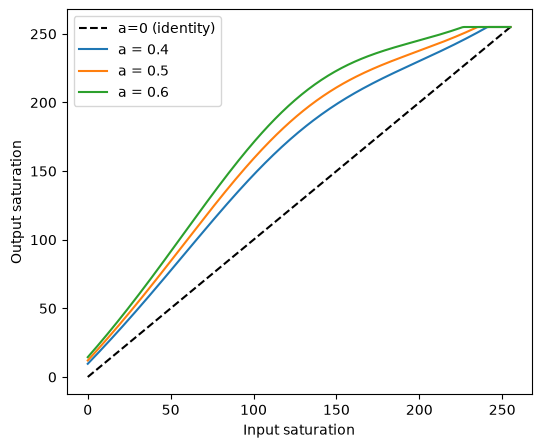

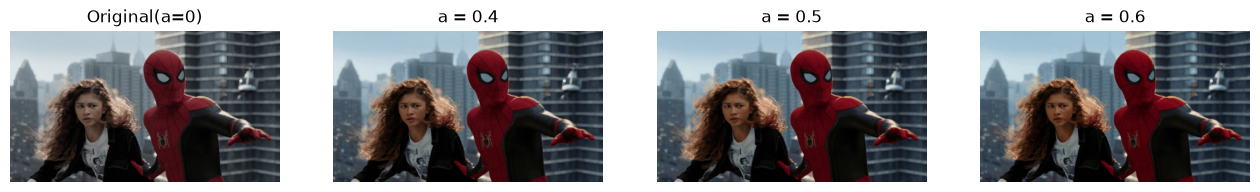

In [74]:
#Increasing the vibrance of a photograph is probably achieved by applying an intensity transformation
#to the saturation plane

spiderman_photo = cv2.imread("images/q4.jpeg")
hsv_planes = cv2.cvtColor(spiderman_photo, cv2.COLOR_BGR2HSV)
#(a) split img into planes
hue_plane, sat_plane, val_plane = cv2.split(hsv_planes)

# H =hue = pure color information 
# S= saturation = purity of color ex: spiderman's red suit highly saturated, gray wall is not saturated
# V= value = brightness of color

sigma_fixed = 70
sat_axis = np.arange(256)

#transformation function
def boost_saturation(sat_channel, alpha_pick):
    sat_float = sat_channel.astype(np.float32)
    bump = alpha_pick * 128 * np.exp(-((sat_float - 128) ** 2) / (2 * sigma_fixed ** 2))
    boosted = np.minimum(sat_float + bump, 255)
    return boosted.astype(np.uint8)

alpha_trials = [0.4, 0.5, 0.6]
result_photos = []
# (b) & (c) applying transformation to saturation plane for different alpha values
for alpha_pick in alpha_trials:
    sat_boosted = boost_saturation(sat_plane, alpha_pick)
    # (d) recombine 3 planes and convert back to BGR
    hsv_boosted = cv2.merge([hue_plane, sat_boosted, val_plane])
    photo_boosted = cv2.cvtColor(hsv_boosted, cv2.COLOR_HSV2BGR)
    result_photos.append(photo_boosted)

fig_curve = plt.figure(figsize=(6, 5))
#(e) display
plt.plot(sat_axis, sat_axis, label="a=0 (identity)", color="black", linestyle="--")
for alpha_pick in alpha_trials:
    bump_curve = alpha_pick * 128 * np.exp(-((sat_axis - 128) ** 2) / (2 * sigma_fixed ** 2))
    curve_vals = np.minimum(sat_axis + bump_curve, 255)
    plt.plot(sat_axis, curve_vals, label=f"a = {alpha_pick}")
plt.xlabel("Input saturation")
plt.ylabel("Output saturation")
plt.legend()
plt.show()

fig_compare, axis_compare = plt.subplots(1, 4, figsize=(16, 4))
axis_compare[0].imshow(cv2.cvtColor(spiderman_photo, cv2.COLOR_BGR2RGB))
axis_compare[0].set_title("Original(a=0)")
axis_compare[0].axis("off")
for slot, alpha_pick, boosted_photo in zip(range(1, 4), alpha_trials, result_photos):
    axis_compare[slot].imshow(cv2.cvtColor(boosted_photo, cv2.COLOR_BGR2RGB))
    axis_compare[slot].set_title(f"a = {alpha_pick}")
    axis_compare[slot].axis("off")
plt.show()

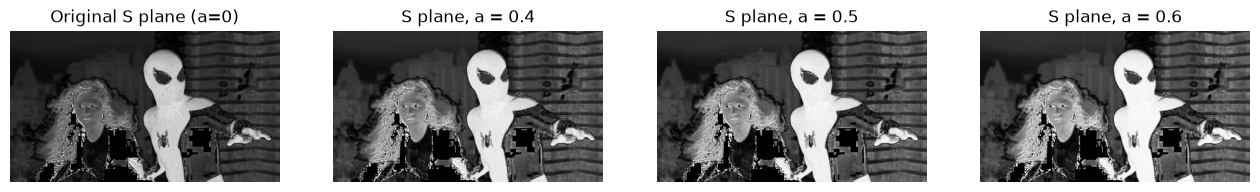

In [75]:
#lets isolate the saturation plane and show the effect of boosting saturation on it alone, 
# without the hue and value planes

fig_sat_only, axis_sat_only = plt.subplots(1, 4, figsize=(16, 4))
axis_sat_only[0].imshow(sat_plane, cmap="gray")
axis_sat_only[0].set_title("Original S plane (a=0)")
axis_sat_only[0].axis("off")
for slot, alpha_pick in zip(range(1, 4), alpha_trials):
    sat_preview = boost_saturation(sat_plane, alpha_pick)
    axis_sat_only[slot].imshow(sat_preview, cmap="gray")
    axis_sat_only[slot].set_title(f"S plane, a = {alpha_pick}")
    axis_sat_only[slot].axis("off")
plt.show()

Question 4

1. Key points in code: sigma=70 ,Tested a=0.4, 0.5, 0.6. 

2. Comparison and interpretation: isolated S-plane  show a=0.6 pushes near-saturated regions toward clipping (255). a=0.4 gives weak pleasing visibility. a=0.5 balances visible increase without clipping.

3. Discussion: a=0.5 reasonable, slightly lower (0.45) could reduce clipping further.

Question 05


[ WARN:0@11800.027] global grfmt_tiff.cpp:123 TIFF_Warning TIFFFetchNormalTag: ASCII value for tag "ImageDescription" does not end in null byte. Forcing it to be null


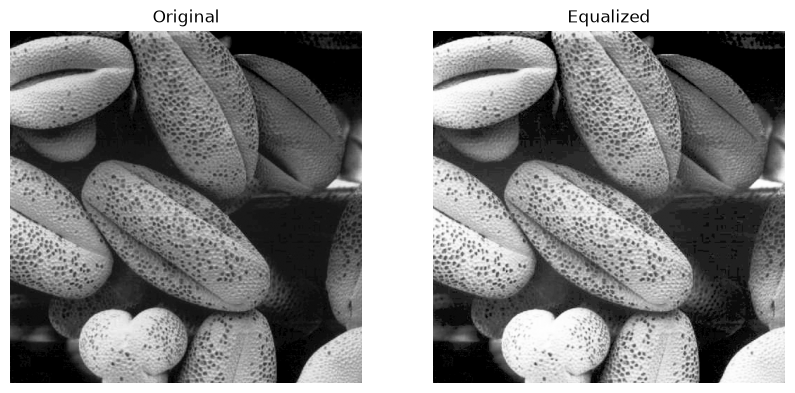

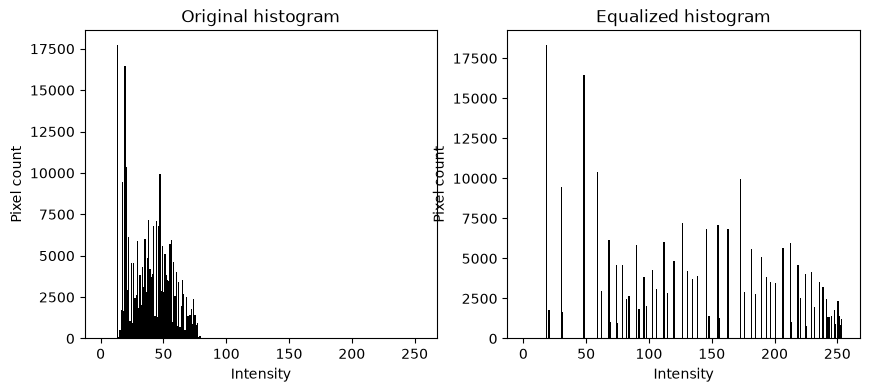

In [ ]:
#Histogram Equalization Function
shell_photo = cv2.imread("images/shells.tif", cv2.IMREAD_GRAYSCALE)

def equalize_hist_manual(gray_img):
    #histogram equalization algorithm
    pixel_count, _ = np.histogram(gray_img.ravel(), bins=256, range=(0, 256))
    running_total = np.cumsum(pixel_count) #cumulative sum
    running_total_scaled = (running_total - running_total.min()) * 255 / (running_total.max() - running_total.min())
    lookup_table = running_total_scaled.astype(np.uint8)
    return lookup_table[gray_img]

shell_equalized = equalize_hist_manual(shell_photo)

fig_shells, axis_shells = plt.subplots(1, 2, figsize=(10, 5))
axis_shells[0].imshow(shell_photo, cmap="gray")
axis_shells[0].set_title("Original")
axis_shells[0].axis("off")
axis_shells[1].imshow(shell_equalized, cmap="gray")
axis_shells[1].set_title("Equalized")
axis_shells[1].axis("off")
plt.show()

fig_shell_hist, axis_shell_hist = plt.subplots(1, 2, figsize=(10, 4))
axis_shell_hist[0].hist(shell_photo.ravel(), bins=256, range=(0, 255), color="black")
axis_shell_hist[0].set_title("Original histogram")
axis_shell_hist[0].set_xlabel("Intensity")
axis_shell_hist[0].set_ylabel("Pixel count")
axis_shell_hist[1].hist(shell_equalized.ravel(), bins=256, range=(0, 255), color="black")
axis_shell_hist[1].set_title("Equalized histogram")
axis_shell_hist[1].set_xlabel("Intensity")
axis_shell_hist[1].set_ylabel("Pixel count")
plt.show()

Question 06


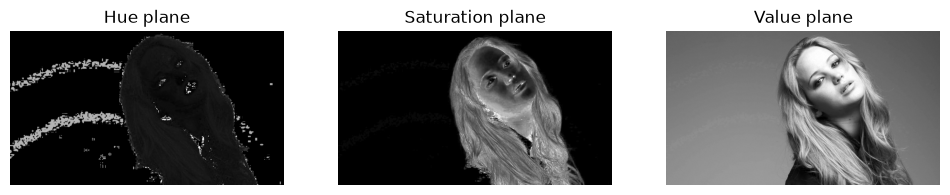

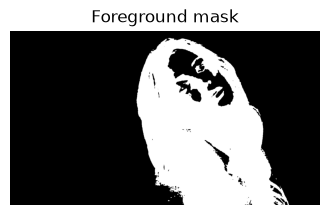

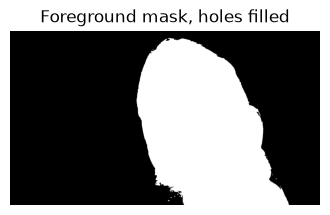

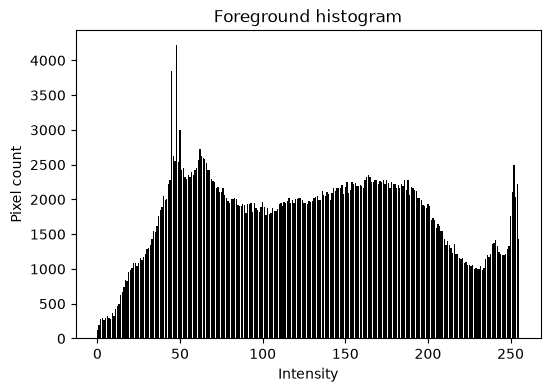

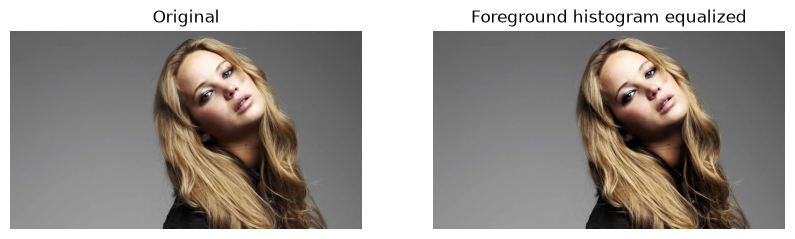

In [67]:
# 6. In this question, we will apply histogram equalization only to the foreground of an image
portrait_photo = cv2.imread("images/q6.jpeg")

# (a) Open the image in Fig. 6, split it into hue, saturation, and values (HSV plane)
# and display these planes in grayscale
hsv_full = cv2.cvtColor(portrait_photo, cv2.COLOR_BGR2HSV)
hue_only, sat_only, val_only = cv2.split(hsv_full)

fig_planes, axis_planes = plt.subplots(1, 3, figsize=(12, 4))
axis_planes[0].imshow(hue_only, cmap="gray")
axis_planes[0].set_title("Hue plane")
axis_planes[0].axis("off")
axis_planes[1].imshow(sat_only, cmap="gray")
axis_planes[1].set_title("Saturation plane")
axis_planes[1].axis("off")
axis_planes[2].imshow(val_only, cmap="gray")
axis_planes[2].set_title("Value plane")
axis_planes[2].axis("off")
plt.show()

# (b) Select the appropriate plane to threshold in extract the foreground mask. 
# A mask is a binary image
# saturation chosen: background is flat gray with low saturation where subject carries visible color
sat_blur = cv2.GaussianBlur(sat_only, (5, 5), 0)
thresh_value, fore_mask = cv2.threshold(sat_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
#Otsu's Thresholding
#creates  black-and-white stencil array fore_mask  (asssign 0 and 1)

plt.figure(figsize=(4, 5))
plt.imshow(fore_mask, cmap="gray")
plt.title("Foreground mask")
plt.axis("off")
plt.show()

# thresholding left small black holes inside the face where skin saturation  too low
# fix by flood-filling from a background corner
# anything unreached by that fill must be an enclosed hole
mask_h, mask_w = fore_mask.shape
flood_fill_mask = np.zeros((mask_h + 2, mask_w + 2), np.uint8)
fore_mask_flooded = fore_mask.copy()
cv2.floodFill(fore_mask_flooded, flood_fill_mask, (0, 0), 255)

holes_only = cv2.bitwise_not(fore_mask_flooded)
fore_mask = fore_mask | holes_only

plt.figure(figsize=(4, 5))
plt.imshow(fore_mask, cmap="gray")
plt.title("Foreground mask, holes filled")
plt.axis("off")
plt.show()

# (c) Now obtain the foreground only using cv.bitwise_and and compute the histogram
fore_value = cv2.bitwise_and(val_only, val_only, mask=fore_mask)
#keeps the brightness values where the mask is white and drops everything else to zero
fore_counts, _ = np.histogram(fore_value[fore_mask > 0].ravel(), bins=256, range=(0, 256))
#histogram for pixels inside foregrnd

plt.figure(figsize=(6, 4))
plt.bar(np.arange(256), fore_counts, color="black")
plt.title("Foreground histogram")
plt.xlabel("Intensity")
plt.ylabel("Pixel count")
plt.show()

# (d) Obtain the cumulative sum of the histogram 
fore_running = np.cumsum(fore_counts)

# (e) histogram-equalize the foreground
fore_total = fore_running[-1]
fore_lookup = np.round((255 / fore_total) * fore_running).astype(np.uint8)
fore_equalized = fore_lookup[fore_value]

# (f) Extract the background and add with the histogram equalized foreground
back_mask = cv2.bitwise_not(fore_mask)# White = Background, Black = Person (inverse stencil)
back_value = cv2.bitwise_and(val_only, val_only, mask=back_mask)
fore_final = cv2.bitwise_and(fore_equalized, fore_equalized, mask=fore_mask)
combined_value = cv2.add(back_value, fore_final) # add both

hsv_combined = cv2.merge([hue_only, sat_only, combined_value])
portrait_result = cv2.cvtColor(hsv_combined, cv2.COLOR_HSV2BGR)

fig_final, axis_final = plt.subplots(1, 2, figsize=(10, 5))
axis_final[0].imshow(cv2.cvtColor(portrait_photo, cv2.COLOR_BGR2RGB))
axis_final[0].set_title("Original")
axis_final[0].axis("off")
axis_final[1].imshow(cv2.cvtColor(portrait_result, cv2.COLOR_BGR2RGB))
axis_final[1].set_title("Foreground histogram equalized")
axis_final[1].axis("off")
plt.show()

Question 6

1. Key points in code: 
saturation plane chosen for thresholding (low-saturation background vs. colored subject). Otsu auto-selects cutoff. Only value plane equalized, hue and saturation untouched.

2. Comparison and interpretation: raw Otsu mask had internal holes in face (low skin saturation near background level). Flood-fill from background corner patched holes without disturbing outer boundary. Final result shows higher contrast on subject only, background unchanged.

3. Discussion: When foreground saturation is non-uniform , a different reliable method should be considered than single-pass thresholding.

Question 07


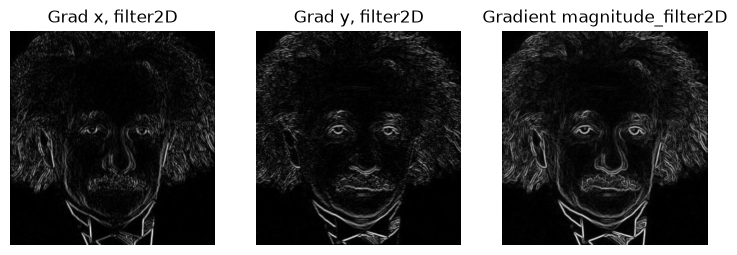

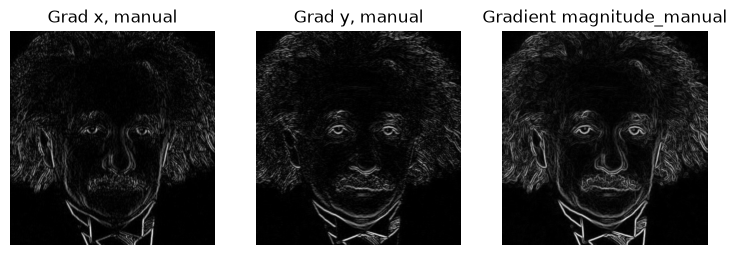

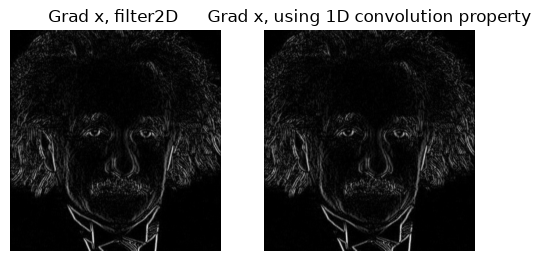

Maximum difference between direct and separable Sobel result: 0.0


In [ ]:
# 7. Filtering with the Sobel operator can compute the gradient. Consider the image shown in Fig. 7
einstein_photo = cv2.imread("images/q7.jpeg", cv2.IMREAD_GRAYSCALE)

# (a) Using the existing filter2D to Sobel filter the image
sobel_x_kernel = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]], dtype=np.float32)
sobel_y_kernel = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]], dtype=np.float32)

grad_x_builtin = cv2.filter2D(einstein_photo, cv2.CV_32F, sobel_x_kernel)
grad_y_builtin = cv2.filter2D(einstein_photo, cv2.CV_32F, sobel_y_kernel)
grad_mag_builtin = np.sqrt(grad_x_builtin ** 2 + grad_y_builtin ** 2)

fig_builtin, axis_builtin = plt.subplots(1, 3, figsize=(9, 3))
axis_builtin[0].imshow(np.abs(grad_x_builtin), cmap="gray")
axis_builtin[0].set_title("Grad x, filter2D")
axis_builtin[0].axis("off")
axis_builtin[1].imshow(np.abs(grad_y_builtin), cmap="gray")
axis_builtin[1].set_title("Grad y, filter2D")
axis_builtin[1].axis("off")
axis_builtin[2].imshow(grad_mag_builtin, cmap="gray")
axis_builtin[2].set_title("Gradient magnitude_filter2D")
axis_builtin[2].axis("off")
plt.show()

# (b) Write your own code to Sobel filter the image
def sobel_filter_manual(gray_img, kernel):
    pad_img = np.pad(gray_img.astype(np.float32), 1, mode="edge")
    height, width = gray_img.shape
    out_img = np.zeros((height, width), dtype=np.float32)
    for row in range(height):
        for col in range(width):
            patch = pad_img[row:row + 3, col:col + 3]
            out_img[row, col] = np.sum(patch * kernel)
    return out_img

grad_x_manual = sobel_filter_manual(einstein_photo, sobel_x_kernel)
grad_y_manual = sobel_filter_manual(einstein_photo, sobel_y_kernel)
grad_mag_manual = np.sqrt(grad_x_manual ** 2 + grad_y_manual ** 2)

fig_manual, axis_manual = plt.subplots(1, 3, figsize=(9, 3))
axis_manual[0].imshow(np.abs(grad_x_manual), cmap="gray")
axis_manual[0].set_title("Grad x, manual")
axis_manual[0].axis("off")
axis_manual[1].imshow(np.abs(grad_y_manual), cmap="gray")
axis_manual[1].set_title("Grad y, manual")
axis_manual[1].axis("off")
axis_manual[2].imshow(grad_mag_manual, cmap="gray")
axis_manual[2].set_title("Gradient magnitude_manual")
axis_manual[2].axis("off")
plt.show()

# (c) Using the property [[1,0,-1],[2,0,-2],[1,0,-1]] = [[1],[2],[1]] * [1,0,-1], carry out Sobel filtering
#lets consider grad x
col_part = np.array([[1], [2], [1]], dtype=np.float32)
row_part = np.array([[1, 0, -1]], dtype=np.float32)

grad_x_separable = cv2.filter2D(cv2.filter2D(einstein_photo, cv2.CV_32F, row_part), cv2.CV_32F, col_part)

fig_separable, axis_separable = plt.subplots(1, 2, figsize=(6, 3))
axis_separable[0].imshow(np.abs(grad_x_builtin), cmap="gray")
axis_separable[0].set_title("Grad x, filter2D ")
axis_separable[0].axis("off")
axis_separable[1].imshow(np.abs(grad_x_separable), cmap="gray")
axis_separable[1].set_title("Grad x, using 1D convolution property")
axis_separable[1].axis("off")
plt.show()

separable_diff = np.abs(grad_x_builtin - grad_x_separable).max()
print("Maximum difference between direct and separable Sobel result:", separable_diff)

Question 7

1. Key points in code: standard 3x3 Sobel kernels used.

2. Comparison and interpretation: manual convolution, filter2D, and separable (1D row + 1D column) results all identical, max difference = 0.0.

3. Discussion: zero difference expected, Sobel kernel is mathematically separable into smoothing [1,2,1] and differencing [1,0,-1] components, same result obtained at lower cost (3+3 multiplications vs. 9).

Question 08


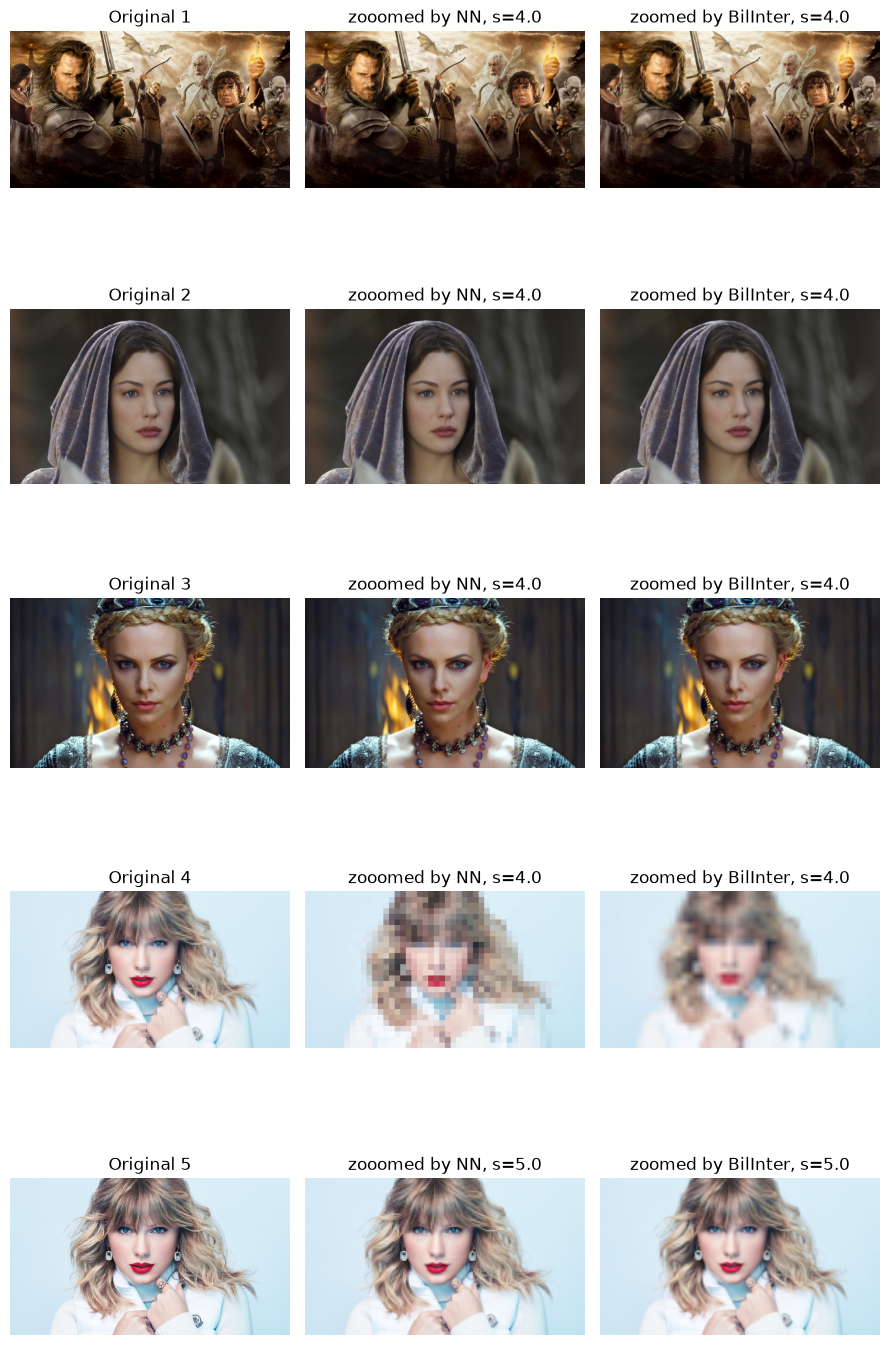

Pair 1 (s=4.0): nearest neighbor SSD = 136.27, bilinear SSD = 200.15
Pair 2 (s=4.0): nearest neighbor SSD = 26.45, bilinear SSD = 49.06
Pair 3 (s=4.0): nearest neighbor SSD = 67.58, bilinear SSD = 98.08
Pair 4 (s=4.0): nearest neighbor SSD = 228.62, bilinear SSD = 330.27
Pair 5 (s=5.0): nearest neighbor SSD = 238.03, bilinear SSD = 286.11


In [70]:
# 8. Write a program to zoom images by a given factor s in (0,10]
# Test the algorithm by computing the normalized SSD when scaling small images by a factor of 4

pair_names = [
    ("im01small.png", "im01.png"),
    ("im02small.png", "im02.png"),
    ("im03small.png", "im03.png"),
    ("im04small.jpg", "im04.jpg"),
    ("im04.jpg", "im05.jpg"),
]

small_photos = [cv2.imread(f"images/{small_name}") for small_name, _ in pair_names]
large_photos = [cv2.imread(f"images/{large_name}") for _, large_name in pair_names]

# (a) nearest-neighbor interpolation
def zoom_nearest(source_img, scale_factor):
    orig_h, orig_w = source_img.shape[:2]
    target_h = int(round(orig_h * scale_factor))
    target_w = int(round(orig_w * scale_factor))
    row_src = (np.arange(target_h) / scale_factor).astype(int)
    row_src = np.clip(row_src, 0, orig_h - 1)
    col_src = (np.arange(target_w) / scale_factor).astype(int)
    col_src = np.clip(col_src, 0, orig_w - 1)
    zoomed_out = source_img[row_src[:, None], col_src[None, :]] # making 2 1D to a 2D array
    return zoomed_out

# (b) bilinear interpolation
def zoom_bilinear(source_img, scale_factor):
    orig_h, orig_w = source_img.shape[:2]
    target_h = int(round(orig_h * scale_factor))
    target_w = int(round(orig_w * scale_factor))
    zoomed_out = np.zeros((target_h, target_w, 3), dtype=np.float32)
    #ode runs through out_row and out_col to visit every empty space in  zoomed img
    src_img_float = source_img.astype(np.float32)
    for out_row in range(target_h):
        map_row = out_row / scale_factor
        row_low = int(map_row)
        row_high = min(row_low + 1, orig_h - 1)
        frac_row = map_row - row_low
        for out_col in range(target_w):
            map_col = out_col / scale_factor
            col_low = int(map_col)
            col_high = min(col_low + 1, orig_w - 1)
            frac_col = map_col - col_low
#the 4 closest actual color values in src_img_float using 
# row_low, row_high, col_low, and col_high

            top_edge = (1 - frac_col) * src_img_float[row_low, col_low] + frac_col * src_img_float[row_low, col_high]
            bottom_edge = (1 - frac_col) * src_img_float[row_high, col_low] + frac_col * src_img_float[row_high, col_high]
            #blends those 4 colors based on frac_row and frac_col
            zoomed_out[out_row, out_col] = (1 - frac_row) * top_edge + frac_row * bottom_edge
    return np.round(zoomed_out).astype(np.uint8)

# scale factor computed from actual image sizes , so every pair zooms correctly
nearest_results = []
bilinear_results = []
scale_used = []
for photo_small, photo_large in zip(small_photos, large_photos):
    row_scale = photo_large.shape[0] / photo_small.shape[0]
    col_scale = photo_large.shape[1] / photo_small.shape[1]
    scale_pick = round((row_scale + col_scale) / 2, 2)
    scale_used.append(scale_pick)
    nearest_results.append(zoom_nearest(photo_small, scale_pick))
    bilinear_results.append(zoom_bilinear(photo_small, scale_pick))

fig_zoom, axis_zoom = plt.subplots(5, 3, figsize=(9, 15))
for row_idx in range(5):
    axis_zoom[row_idx, 0].imshow(cv2.cvtColor(large_photos[row_idx], cv2.COLOR_BGR2RGB))
    axis_zoom[row_idx, 0].set_title(f"Original {row_idx + 1}")
    axis_zoom[row_idx, 0].axis("off")
    axis_zoom[row_idx, 1].imshow(cv2.cvtColor(nearest_results[row_idx], cv2.COLOR_BGR2RGB))
    axis_zoom[row_idx, 1].set_title(f"zooomed by NN, s={scale_used[row_idx]}")
    axis_zoom[row_idx, 1].axis("off")
    axis_zoom[row_idx, 2].imshow(cv2.cvtColor(bilinear_results[row_idx], cv2.COLOR_BGR2RGB))
    axis_zoom[row_idx, 2].set_title(f"zoomed by BilInter, s={scale_used[row_idx]}")
    axis_zoom[row_idx, 2].axis("off")
plt.tight_layout()
plt.show()

# normalized SSD when scaling up by a factor of 4, compared with the original images
def normalized_ssd(compare_img, reference_img):
    ref_h, ref_w = reference_img.shape[:2]
    compare_cropped = compare_img[:ref_h, :ref_w].astype(np.float32)
    #this crops the zoomed image to the exact same matrix grid size as the reference
    reference_float = reference_img.astype(np.float32)
    #convert int to float
    raw_ssd = np.sum((compare_cropped - reference_float) ** 2)
    pixel_total = ref_h * ref_w * reference_img.shape[2]
    return raw_ssd / pixel_total

for idx in range(5):
    ssd_nearest = normalized_ssd(nearest_results[idx], large_photos[idx])
    ssd_bilinear = normalized_ssd(bilinear_results[idx], large_photos[idx])
    print(f"Pair {idx + 1} (s={scale_used[idx]}): nearest neighbor SSD = {ssd_nearest:.2f}, bilinear SSD = {ssd_bilinear:.2f}")

Question 8

1. Key points in code: zoom factor computed from actual large/small image size ratio per pair, not assumed fixed, since pair 5 had no stated factor.

2. Comparison and interpretation: nearest neighbor gave lower (better) normalized SSD across all 5 pairs amiidst bilinear method output looking visually smoother.

3. Discussion: 
Nearest-neighbor gets a better (lower) SSD score because the small images were originally made by simply skipping pixels, which is the exact same logic nearest-neighbor uses to scale them back up.

 On the other hand, bilinear interpolation takes a weighted average of the surrounding pixels. While this averaging removes  artifacts and looks much smoother to the human eye, it changes the exact numerical color values on sharp edges and textures, which mathematically increases the calculation error (SSD).

Question 09


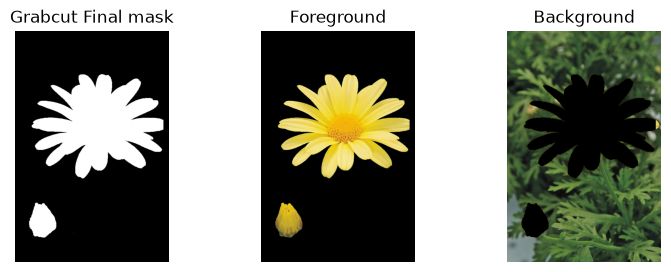

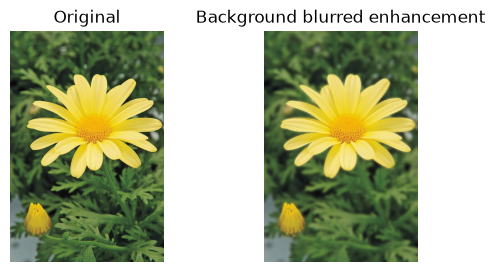

In [13]:
# 9. Fig. 8 shows a flower image with both the foreground and background are in focus
flower_photo = cv2.imread("images/q9.jpeg")

# (a) Use grabCut to segment the image. Show the final segmentation mask, foreground image, and background image
grab_mask = np.zeros(flower_photo.shape[:2], np.uint8) #empty 2D intialized
back_model = np.zeros((1, 65), np.float64)
fore_model = np.zeros((1, 65), np.float64)

photo_h, photo_w = flower_photo.shape[:2]
#20-pixel margin around all four edges of the img
margin = 20
#grab_rect defines a bounding box using the standard format
# (x_start, y_start, width, height)
# we must subtract the margin space from both sides of the total canvas size
#so box is centered
grab_rectangle = (margin, margin, photo_w - 2 * margin, photo_h - 2 * margin)

cv2.grabCut(flower_photo, grab_mask, grab_rectangle, back_model, fore_model, 5, cv2.GC_INIT_WITH_RECT)
#Every pixel inside grab_mask gets assigned 
#cv2.GC_BGD (0): Definite Background
#cv2.GC_FGD (1): Definite Foreground
#cv2.GC_PR_BGD (2): Probable Background
#v2.GC_PR_FGD (3): Probable Foreground

final_mask = np.where((grab_mask == cv2.GC_FGD) | (grab_mask == cv2.GC_PR_FGD), 1, 0).astype(np.uint8)
#foreground=1 , bckgnd=0 so we can multiply the original image by this mask to isolate the foreground and background

flower_foreground = flower_photo * final_mask[:, :, np.newaxis]
#now lets inverse stencil to get backgnd
flower_background = flower_photo * (1 - final_mask[:, :, np.newaxis])

fig_grabcut, axis_grabcut = plt.subplots(1, 3, figsize=(9, 3))
axis_grabcut[0].imshow(final_mask, cmap="gray")
axis_grabcut[0].set_title("Grabcut Final mask")
axis_grabcut[0].axis("off")
axis_grabcut[1].imshow(cv2.cvtColor(flower_foreground, cv2.COLOR_BGR2RGB))
axis_grabcut[1].set_title("Foreground")
axis_grabcut[1].axis("off")
axis_grabcut[2].imshow(cv2.cvtColor(flower_background, cv2.COLOR_BGR2RGB))
axis_grabcut[2].set_title("Background")
axis_grabcut[2].axis("off")
plt.show()

# (b) Produce an enhanced image with a substantially blurred background. Display the original image alongside the enhanced image
blurred_full = cv2.GaussianBlur(flower_photo, (25, 25), 0)
mask_3ch = final_mask[:, :, np.newaxis]
flower_enhanced = flower_photo * mask_3ch + blurred_full * (1 - mask_3ch)
# px=1 then not blurred, px=0 then blurred
flower_enhanced = flower_enhanced.astype(np.uint8)

fig_enhance, axis_enhance = plt.subplots(1, 2, figsize=(6, 3))
axis_enhance[0].imshow(cv2.cvtColor(flower_photo, cv2.COLOR_BGR2RGB))
axis_enhance[0].set_title("Original")
axis_enhance[0].axis("off")
axis_enhance[1].imshow(cv2.cvtColor(flower_enhanced, cv2.COLOR_BGR2RGB))
axis_enhance[1].set_title("Background blurred enhancement")
axis_enhance[1].axis("off")
plt.show()

c. Why is the background just beyond the edge of the flower quite dark in the enhanced image?

cv2.GaussianBlur uses a large window to average pixel colors together. At the border, it  mixes the sharp flower colors into the background colors, creating a smudged color . final_mask has a sharp edge. 
At, flower_enhanced = flower_photo * mask_3ch + blurred_full * (1 - mask_3ch),when px=0 at boundary, then blurred_full remains  which is already contaminated by the dark colors of the background during the Gaussian Blurr leaving  background just beyond the edge of the flower quite dark in the enhanced image. 

Question 9

1. Key points in code: grabCut rectangle uses 20px margin from image edges , 5 iterations.

2. Comparison and interpretation: mask correctly isolates flower and bud, leaves leafy background separated cleanly. 


Question 10

In [14]:
pip install scikit-image

Note: you may need to restart the kernel to use updated packages.


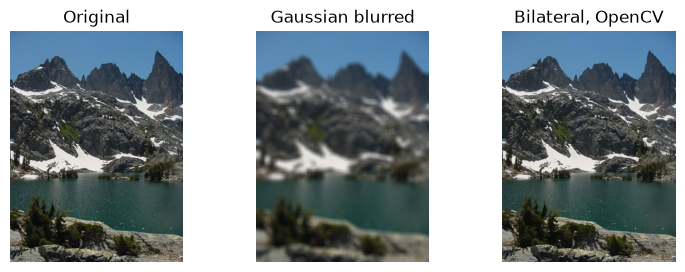

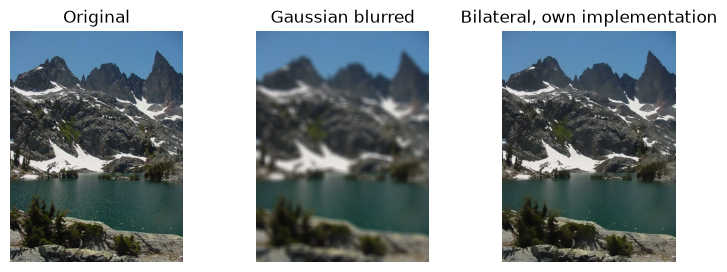

Structural similarity between OpenCV and own bilateral filter result: 0.9576


In [71]:
# 10. Fig. 9 shows an image of Lake Minaret. Smoothen the image while keeping the edges sharp
lake_photo = cv2.imread("images/q10.jpeg")

# (a) Use OpenCV's bilateralFilter with sigma_s and sigma_r of your choice
# Display the original, Gaussian blurred image with a similar kernel, and bilateral filtered images side-by-side
sigma_space_pick = 9 #Gives more weight to pixels that are close by
sigma_range_pick = 15 #Gives more weight to pixels that have a similar color
kernel_span = 9 #9x9

lake_gaussian = cv2.GaussianBlur(lake_photo, (kernel_span, kernel_span), sigma_space_pick)
lake_bilateral_cv = cv2.bilateralFilter(lake_photo, kernel_span, sigma_range_pick, sigma_space_pick)

fig_partA, axis_partA = plt.subplots(1, 3, figsize=(9, 3))
axis_partA[0].imshow(cv2.cvtColor(lake_photo, cv2.COLOR_BGR2RGB))
axis_partA[0].set_title("Original")
axis_partA[0].axis("off")
axis_partA[1].imshow(cv2.cvtColor(lake_gaussian, cv2.COLOR_BGR2RGB))
axis_partA[1].set_title("Gaussian blurred")
axis_partA[1].axis("off")
axis_partA[2].imshow(cv2.cvtColor(lake_bilateral_cv, cv2.COLOR_BGR2RGB))
axis_partA[2].set_title("Bilateral, OpenCV")
axis_partA[2].axis("off")
plt.show()

# (b) Implement your own bilateral filter and compare with OpenCV's bilateralFilter
# Display the original, Gaussian blurred, and bilateral filtered images side-by-side, with a quantitative comparison
def manual_biltaeral_filter(color_img, sigma_space, sigma_range, border_padding):
    gray_ref = cv2.cvtColor(color_img, cv2.COLOR_BGR2GRAY).astype(np.float32)
    img_float = color_img.astype(np.float32)
    padded_gray = np.pad(gray_ref, border_padding, mode="edge")
    padded_color = np.pad(img_float, ((border_padding, border_padding), (border_padding, border_padding), (0, 0)), mode="edge")
    #padding both gray scale and clr images by 4 since kernel 9x9

    win_coords = np.arange(-border_padding, border_padding + 1)
    #[-4, -3, -2, -1, 0, 1, 2, 3, 4]
    grid_y, grid_x = np.meshgrid(win_coords, win_coords, indexing="ij")
    #merging two 1D arrays as 2D kernel coordinates matrix
    space_weight = np.exp(-(grid_x ** 2 + grid_y ** 2) / (2 * sigma_space ** 2))
    #calculate guassian space weights

    height, width = gray_ref.shape
    output_img = np.zeros_like(img_float)

    for row in range(height):
        for col in range(width):
            #9x9 area of interest around the pixel at (row, col)
            #gray scale
            gray_patch = padded_gray[row:row + 2 * border_padding + 1, col:col + 2 * border_padding + 1]
            center_gray = gray_ref[row, col]
            #calculate guassian range weights
            range_weight = np.exp(-((gray_patch - center_gray) ** 2) / (2 * sigma_range ** 2))
            combined_weight = space_weight * range_weight
            weight_total = combined_weight.sum()

            #color scale mapping, apply the same weights to each channel of the color image

            color_patch = padded_color[row:row + 2 * border_padding + 1, col:col + 2 * border_padding + 1, :]
            for channel in range(3):
                output_img[row, col, channel] = np.sum(combined_weight * color_patch[:, :, channel]) / weight_total

    return np.round(output_img).astype(np.uint8)

lake_bilateral_manual = manual_biltaeral_filter(lake_photo, sigma_space_pick, sigma_range_pick, border_padding=4)

fig_partB, axis_partB = plt.subplots(1, 3, figsize=(9, 3))
axis_partB[0].imshow(cv2.cvtColor(lake_photo, cv2.COLOR_BGR2RGB))
axis_partB[0].set_title("Original")
axis_partB[0].axis("off")
axis_partB[1].imshow(cv2.cvtColor(lake_gaussian, cv2.COLOR_BGR2RGB))
axis_partB[1].set_title("Gaussian blurred")
axis_partB[1].axis("off")
axis_partB[2].imshow(cv2.cvtColor(lake_bilateral_manual, cv2.COLOR_BGR2RGB))
axis_partB[2].set_title("Bilateral, own implementation")
axis_partB[2].axis("off")
plt.show()

from skimage.metrics import structural_similarity as ssim_score

gray_cv_result = cv2.cvtColor(lake_bilateral_cv, cv2.COLOR_BGR2GRAY)
gray_manual_result = cv2.cvtColor(lake_bilateral_manual, cv2.COLOR_BGR2GRAY)

similarity_index, _ = ssim_score(gray_cv_result, gray_manual_result, full=True)
print("Structural similarity between OpenCV and own bilateral filter result:", round(similarity_index, 4))
#A score of 1.0 means they are structurally identical.


Question 10

1. Key points in code: sigma_space, sigma_range, kernel size not specified in assignment. Kernel = 9x9, sigma_space is kernel radius so window contributes fully, sigma_range = 15  to preserve rock/water/sky boundaries.

2. Comparison and interpretation: Gaussian blur smooths uniformly, blurs edges. Both bilateral versions preserve edge sharpness. Manual implementation matches OpenCV's result, SSIM = 0.9576.

3. Discussion: grayscale-based range weight is a lighter approximation of true multi-channel bilateral filtering (This may be missing color differences that grayscale alone can't see (ex: two pixels with the same brightness but different hue)).